In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src')

from wale.LoadSimulations import get_smoothed_app_pdf, get_smoothed_pdf
from wale.InitializeVariables import InitialiseVariables
from wale.VarianceCalculator import Variance
from wale.ComputePDF import computePDF
from wale.RateFunction import get_scaled_cgf, get_scaled_cgf_1cell
from wale.CriticalPoints import find_critical_points_for_cosmo, find_lambda_range_1cell

## loading sim data vectors

In [2]:
def fetch_sim_data(theta):
    file_kappa = f'../data/all_kappas_halofit_nobaryons_bin4_theta{theta}.0_ratio2.0.npy'
    file_l1_norms = f'../data/all_l1_norms_halofit_nobaryons_bin4_theta{theta}.0_ratio2.0.npy'
    file_variance = f'../data/all_variances_halofit_nobaryons_bin4_theta{theta}.0_ratio2.0.npy'
    file_variance_fiducial = f'../data/all_variances_fiducial_nobaryons_bin4_theta{theta}.0_ratio2.0.npy'
    return np.load(file_kappa), np.load(file_l1_norms), np.load(file_variance), np.load(file_variance_fiducial)

params = np.load('../data/selected_params_halofit.npy')

theta1 = 40
kappa_sim, l1_norms_sim, variance_sim, variance_fid = fetch_sim_data(theta=theta1)

#get the shape of all the data vectors
print(kappa_sim.shape)
print(l1_norms_sim.shape)
print(variance_sim.shape)
print(variance_fid.shape)
print(params.shape)

(1299, 400)
(1299, 400)
(1299,)
(200,)
(1299, 6)


## setting the params for theory 

In [8]:
from joblib import Parallel, delayed

# Log-spaced ℓ grid used for all C_ℓ outputs (fixed across all cosmologies)
ELLS = np.unique(np.geomspace(10, 5000, 60).astype(int)).astype(float)


def _compute_one_cosmo(i, param_i, kappa_bins, l1_sim_i, var_sim_i,
                       theta1, nz_file, nplanes, kmin, kmax, dk, nlambdas, filter_type,
                       nz_data=None):
    """Worker: compute theory PDF + L1 + C_ℓ for one cosmology. Safe for loky (spawn)."""
    import numpy as np
    import sys, os
    sys.path.insert(0, os.path.join(os.path.dirname(__file__) if '__file__' in dir() else '.', '../src'))
    import jax
    jax.config.update("jax_enable_x64", True)

    from wale.InitializeVariables import InitialiseVariables
    from wale.VarianceCalculator import Variance
    from wale.ComputePDF import computePDF
    from wale.CriticalPoints import find_critical_points_for_cosmo

    Om, sigma8, w0, h_100, ns, Ob = param_i
    h  = h_100 / 100.
    Oc = Om - Ob
    wa = 0.0

    variables = InitialiseVariables(
        h=h, Oc=Oc, Ob=Ob, w=w0, wa=wa, sigma8=sigma8,
        dk=dk, kmin=kmin, kmax=kmax, ns=ns,
        nz_file=nz_file,
        zs=None,
        variability=False,
        theta1=theta1,
        nplanes=nplanes,
        numberofrealisations=1,
    )

    var_th2 = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)

    sigmasq_map_2c_th = float(np.sum(
        variables.dchi * variables.lensingweights**2 * np.array([
            float(var_th2.get_sig_slice(z, chi * variables.theta1_radian,
                                            chi * variables.theta2_radian))
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    ))

    variables.recal_value = sigmasq_map_2c_th / var_sim_i

    sp_th, ln_th = find_critical_points_for_cosmo(
        variables, var_th2, ngrid_critical=5, plot=False, min_z=0, max_z=5
    )
    lambdas = (np.linspace(ln_th, sp_th, nlambdas)
               if (sp_th is not None and ln_th is not None)
               else np.linspace(-400, 1400, nlambdas))
    variables.lambdas = lambdas

    pdf_th2   = computePDF(variables, var_th2, kappa=kappa_bins, single_cell=False)
    kappa_th2 = np.array(pdf_th2.kappa_values)
    p_th2     = np.array(pdf_th2.pdf_values)
    l1_th2    = np.abs(kappa_th2) * p_th2

    # ── Discrete-plane Limber C_ℓ^κκ ────────────────────────────────────────
    # Matches the simulation's 69-shell discretization exactly.
    # Formula:  C_ℓ ≈ Σ_i (dchi / chi_i²) W_i² P_nl(k_ℓ(chi_i), z_i)
    #           k_ℓ(chi) = (ℓ + 0.5) / chi
    #
    # Uses get_nonlinear_pk (full PyCCL k-range) instead of the LDT pnl dict
    # (kmax=1 Mpc⁻¹) so high-ℓ modes are correctly captured.
    ells  = np.unique(np.geomspace(10, 5000, 60).astype(int)).astype(float)
    cls   = np.zeros(len(ells))
    # Per-plane weight:  dchi / chi² × W²
    plane_weights = variables.dchi / variables.chis**2 * variables.lensingweights**2
    for iz, (z_pl, chi_pl, pw) in enumerate(
            zip(variables.redshifts, variables.chis, plane_weights)):
        k_ells = (ells + 0.5) / chi_pl           # (n_ells,) Mpc⁻¹
        pk_ells = variables.cosmo.get_nonlinear_pk(z_pl, ks=k_ells)  # (n_ells,)
        cls += pw * pk_ells

    return i, kappa_th2, p_th2, l1_th2, sigmasq_map_2c_th, variables.recal_value, cls


In [ ]:
PARAM_NAMES = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

# ── Survey / grid settings ───────────────────────────────────────────────────
tomo_bin    = 3
nz_file     = f"../data/nz/nz_stage3_{tomo_bin+1}_GRID.txt"
nplanes     = 69
kmin        = 1e-3
kmax        = 1.
dk          = 0.001
nlambdas    = 61
filter_type = 'tophat'

n_cosmo = 1299          # set to len(params) to run all 1299
n_bins  = kappa_sim.shape[1]
n_ells  = len(ELLS)

# ── Run in parallel ──────────────────────────────────────────────────────────
n_jobs = 4

results = Parallel(n_jobs=n_jobs, backend='loky', verbose=5)(
    delayed(_compute_one_cosmo)(
        i, params[i], kappa_sim[i], l1_norms_sim[i], variance_sim[i],
        theta1, nz_file, nplanes, kmin, kmax, dk, nlambdas, filter_type
    )
    for i in range(n_cosmo)
)

# ── Collect results (results arrive out of order) ────────────────────────────
out_params        = np.zeros((n_cosmo, 6))
out_kappa         = np.zeros((n_cosmo, n_bins))
out_pdf_theory    = np.zeros((n_cosmo, n_bins))
out_l1_theory     = np.zeros((n_cosmo, n_bins))
out_l1_sim        = np.zeros((n_cosmo, n_bins))
out_variance_ldt  = np.zeros(n_cosmo)
out_variance_sim  = np.zeros(n_cosmo)
out_recal         = np.zeros(n_cosmo)
out_cls           = np.zeros((n_cosmo, n_ells))

for idx, kappa_th2, p_th2, l1_th2, sig2_ldt, recal, cl_kk in results:
    out_params[idx]       = params[idx]
    out_kappa[idx]        = kappa_th2
    out_pdf_theory[idx]   = p_th2
    out_l1_theory[idx]    = l1_th2
    out_l1_sim[idx]       = l1_norms_sim[idx]
    out_variance_ldt[idx] = sig2_ldt
    out_variance_sim[idx] = variance_sim[idx]
    out_recal[idx]        = recal
    out_cls[idx]          = cl_kk

# ── Quick moment summary ─────────────────────────────────────────────────────
def pdf_moment(kappa, pdf, order):
    dk = kappa[1] - kappa[0]
    mean = np.sum(kappa * pdf) * dk
    if order == 1:
        return mean
    return np.sum((kappa - mean)**order * pdf) * dk

print(f"\n{'i':>4}  {'var_th':>10}  {'var_sim':>10}  {'ratio':>7}  {'skew':>7}  {'kurt':>7}")
for i in range(n_cosmo):
    kt, pt = out_kappa[i], out_pdf_theory[i]
    v  = pdf_moment(kt, pt, 2)
    sk = pdf_moment(kt, pt, 3) / v**1.5
    ku = pdf_moment(kt, pt, 4) / v**2 - 3.0
    print(f"{i:>4}  {v:>10.4e}  {out_variance_sim[i]:>10.4e}  {v/out_variance_sim[i]:>7.4f}  {sk:>7.3f}  {ku:>7.3f}")

# ── Save L1 / PDF file ───────────────────────────────────────────────────────
outfile = f"../data/theory_2cell_{filter_type}_theta{theta1}_bin{tomo_bin+1}.npz"
np.savez_compressed(
    outfile,
    params       = out_params,
    param_names  = np.array(PARAM_NAMES),
    kappa_bins   = out_kappa,
    pdf_theory   = out_pdf_theory,
    l1_theory    = out_l1_theory,
    l1_sim       = out_l1_sim,
    variance_ldt = out_variance_ldt,
    variance_sim = out_variance_sim,
    recal_value  = out_recal,
    theta        = theta1,
    tomo_bin     = tomo_bin + 1,
    filter_type  = np.array(filter_type),
    n_cosmo      = n_cosmo,
)
print(f"Saved → {outfile}")

# ── Save C_ℓ file (separate — no dependence on filter/theta) ────────────────
cls_file = f"../data/theory_cls_bin{tomo_bin+1}.npz"
np.savez_compressed(
    cls_file,
    params      = out_params,
    param_names = np.array(PARAM_NAMES),
    ells        = ELLS,
    cls         = out_cls,
    tomo_bin    = tomo_bin + 1,
    n_cosmo     = n_cosmo,
)
print(f"Saved → {cls_file}")


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


   Using scalar spectral index ns = 1.0075

Initialised Cosmology:
  h = 0.78625, Oc = 0.289375, Ob = 0.035625, w = -1.0623125, wa = 0.0, sigma8 = 0.8375
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
   Using scalar spectral index ns = 1.0075

Initialised Cosmology:
  h = 0.78625, Oc = 0.289375, Ob = 0.035625, w = -1.0623125, wa = 0.0, sigma8 = 0.8375
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled
      Variability: disabled
   Using scalar spectral index ns = 1.0075

Initialised Cosmology:
  h = 0.78625, Oc = 0.289375, Ob = 0.035625, w = -1.0623125, wa = 0.0, sigma8 = 0.8375
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled
   Using scalar spectral index ns = 1.0075

Initialised Cosmology:
  h = 0.78625, Oc = 0.289375, Ob = 0.035625, w = -1.06

[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  3.3min


   Using scalar spectral index ns = 0.91375

Initialised Cosmology:
  h = 0.814375, Oc = 0.17781249999999998, Ob = 0.0346875, w = -1.11440625, wa = 0.0, sigma8 = 0.68125
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled
   Using scalar spectral index ns = 0.9465625

Initialised Cosmology:
  h = 0.72578125, Oc = 0.22648437500000002, Ob = 0.039140625, w = -0.9971953125, wa = 0.0, sigma8 = 0.6578125
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled
   Using scalar spectral index ns = 0.9465625

Initialised Cosmology:
  h = 0.72578125, Oc = 0.22648437500000002, Ob = 0.039140625, w = -0.9971953125, wa = 0.0, sigma8 = 0.6578125
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled


/home/vtinnane/miniforge3/envs/wale/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


   Using scalar spectral index ns = 0.9465625

Initialised Cosmology:
  h = 0.72578125, Oc = 0.22648437500000002, Ob = 0.039140625, w = -0.9971953125, wa = 0.0, sigma8 = 0.6578125
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled
   Using scalar spectral index ns = 0.9465625

Initialised Cosmology:
  h = 0.72578125, Oc = 0.22648437500000002, Ob = 0.039140625, w = -0.9971953125, wa = 0.0, sigma8 = 0.6578125
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled
   Using scalar spectral index ns = 0.9465625

Initialised Cosmology:
  h = 0.72578125, Oc = 0.22648437500000002, Ob = 0.039140625, w = -0.9971953125, wa = 0.0, sigma8 = 0.6578125
  k-range: [0.001, 1.0] with step dk = 0.001

the angles are:  0.011635528346628864  and  0.023271056693257727
      Variability: disabled
   Using scalar spectral index ns = 0.94656

[Parallel(n_jobs=4)]: Done  18 out of  20 | elapsed:  5.5min remaining:   36.5s



   i      var_th     var_sim    ratio     skew     kurt
   0  5.0126e-06  5.0116e-06   1.0002   -0.163    0.133
   1  4.9524e-06  4.9514e-06   1.0002   -0.162    0.131
   2  4.9913e-06  4.9903e-06   1.0002   -0.162    0.132
   3  4.9800e-06  4.9789e-06   1.0002   -0.162    0.132
   4  4.9776e-06  4.9766e-06   1.0002   -0.162    0.132
   5  4.9141e-06  4.9131e-06   1.0002   -0.161    0.130
   6  4.9219e-06  4.9209e-06   1.0002   -0.161    0.130
   7  1.9378e-06  1.9371e-06   1.0004   -0.147    0.103
   8  1.9254e-06  1.9247e-06   1.0004   -0.146    0.103
   9  1.9127e-06  1.9121e-06   1.0004   -0.146    0.102
  10  1.9015e-06  1.9008e-06   1.0004   -0.145    0.101
  11  1.9080e-06  1.9073e-06   1.0004   -0.146    0.102
  12  1.9305e-06  1.9298e-06   1.0004   -0.147    0.103
  13  1.9121e-06  1.9114e-06   1.0004   -0.146    0.102
  14  2.2246e-06  2.2239e-06   1.0003   -0.140    0.094
  15  2.2165e-06  2.2157e-06   1.0003   -0.140    0.093
  16  2.2280e-06  2.2272e-06   1.0003   -0.140 

[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed:  5.7min finished


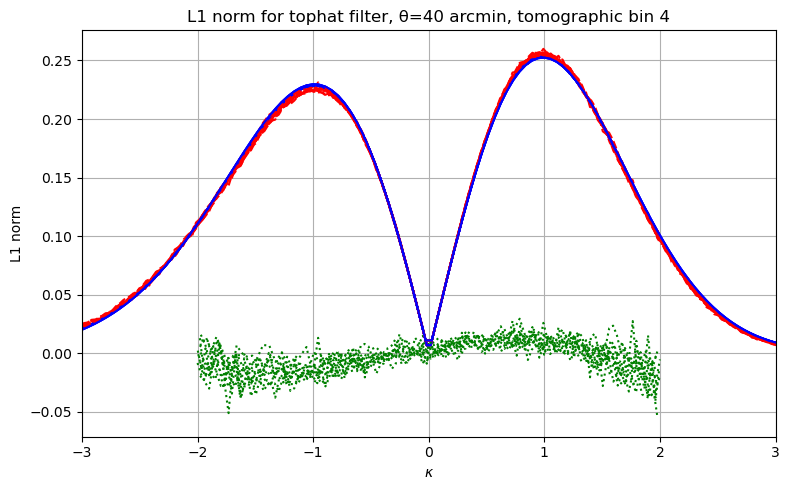

In [13]:
plt.figure(figsize=(8, 5))

for i in range(10):
    
    if np.any(out_l1_sim[i] < 0):
        print(f"Warning: negative L1 norm in sim for cosmology {i}")
    if np.any(out_l1_theory[i] < 0):
        print(f"Warning: negative L1 norm in theory for cosmology {i}")
    if np.any(out_pdf_theory[i] < 0):
        print(f"Warning: negative PDF values in theory for cosmology {i}")
        ind = np.where(out_pdf_theory[i] < 0)[0]
        print(f"Negative PDF at indices: {ind}, kappa values: {out_kappa[i][ind]}, pdf values: {out_pdf_theory[i][ind]}") 
    sigma = np.sqrt(variance_sim[i])
    plt.plot(out_kappa[i]/sigma, out_l1_sim[i], linestyle='dashed', c='red')
    plt.plot(out_kappa[i]/sigma, out_l1_theory[i], c='blue')
    residual = ( out_l1_sim[i] - out_l1_theory[i] ) / (out_l1_sim[i]+1e-10)  # add small number to avoid division by zero
    #get mask upto 2sigma around mean kappa
    mask = (out_kappa[i] >= -2 * sigma) & (out_kappa[i] <= 2 * sigma)
    plt.plot(out_kappa[i][mask]/sigma, residual[mask], linestyle='dotted', c='green')
plt.xlim(-3, 3)

plt.xlabel(r'$\kappa$')
plt.ylabel(r'L1 norm')
plt.title(f'L1 norm for {filter_type} filter, θ={theta1} arcmin, tomographic bin {tomo_bin+1}')
plt.grid()
plt.tight_layout()
plt.show()  

Text(0, 0.5, '$C_\\ell^{\\kappa\\kappa}$')

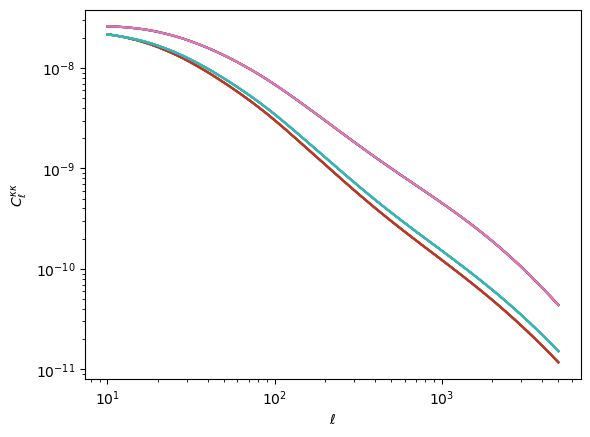

In [36]:
plt.plot(ELLS, out_cls[:].T)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{\kappa\kappa}$')